# GW-ODW 2026 Data Challenge - Challenge 3

![GW Open Data Workshop](../../assets/odw.jpeg)

## Challenge 3 (4 points) -- Intermediate
Search for a loud event in realistic data:

Use the data file `challenge3.gwf` with channel `H1:CHALLENGE3`.
This is real LIGO data from O2, though the time labels are adjusted and some simulated signals are added.
The data contains a loud simulated signal with $m_1 = m_2 = 10 M_\odot$.

## Instructions

1.  **Load the data** from `challenge3.gwf` (URL: `https://dcc.ligo.org/public/0187/G2300818/001/challenge3.gwf`). Channel: `H1:CHALLENGE3`.
2.  **Generate a template** using `SEOBNRv4_opt` with $m_1=m_2=10 M_\odot$.
3.  **Calculate the PSD** of the data.
4.  **Compute the SNR time series** and find the peak SNR.

## Setup: Install necessary libraries

In [1]:
# Ignore warnings (optional)
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

import sys

!{sys.executable} -m pip install gwpy lalsuite pycbc

print("gwpy, lalsuite, and pycbc installed successfully.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 24.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 MB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 104.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.4/300.4 kB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.2/45.2 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.7/168.7 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.0/115.0 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.1/51.1 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.1/203.1 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.1/48.1 MB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 91.0 MB/s eta 0:00:00
  Attempting uninstall: cryptography
    Found existi

## Step 1: Load the data into memory

In [2]:
from gwpy.timeseries import TimeSeries
import requests

data_url = 'https://dcc.ligo.org/public/0187/G2300818/001/challenge3.gwf'
channel_name = 'H1:CHALLENGE3'
local_file = 'challenge3.gwf'

print(f"Downloading {data_url}...")
r = requests.get(data_url)
with open(local_file, 'wb') as f:
    f.write(r.content)

ts = TimeSeries.read(local_file, channel_name)
print(f"Data loaded successfully: {ts.sample_rate} sampling rate, {ts.duration} duration.")

Data loaded successfully: 4096.0 Hz sampling rate, 4096.0 s duration.


## Step 2: Generate Template Waveform

We generate a time-domain template using the `SEOBNRv4_opt` approximant for two 10 solar mass black holes.

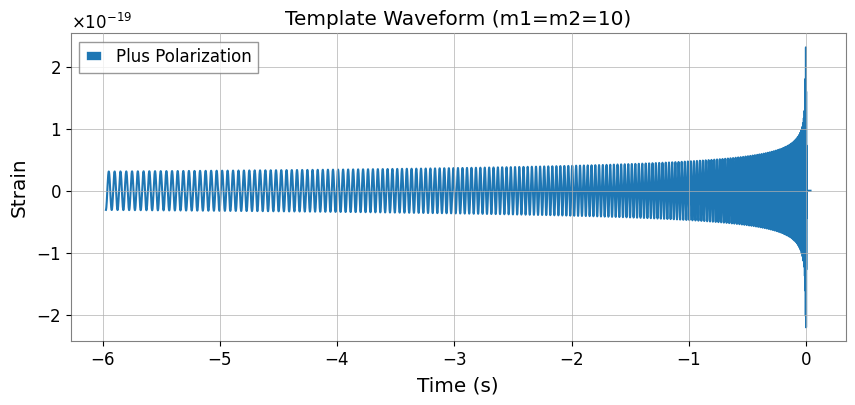

In [ ]:
from pycbc.waveform import get_td_waveform
import matplotlib.pyplot as plt

hp, hc = get_td_waveform(approximant="SEOBNRv4_opt",
                         mass1=10,
                         mass2=10,
                         delta_t=1.0/ts.sample_rate.value,
                         f_lower=20)

plt.figure(figsize=(10, 4))
plt.plot(hp.sample_times, hp, label='Plus Polarization')
plt.xlabel('Time (s)')
plt.ylabel('Strain')
plt.title('Template Waveform (m1=m2=10)')
plt.legend()
plt.show()

## Step 3: Calculate the PSD of the data

We calculate the Power Spectral Density (PSD) to characterize the noise, plotting from 20 Hz to the Nyquist frequency.

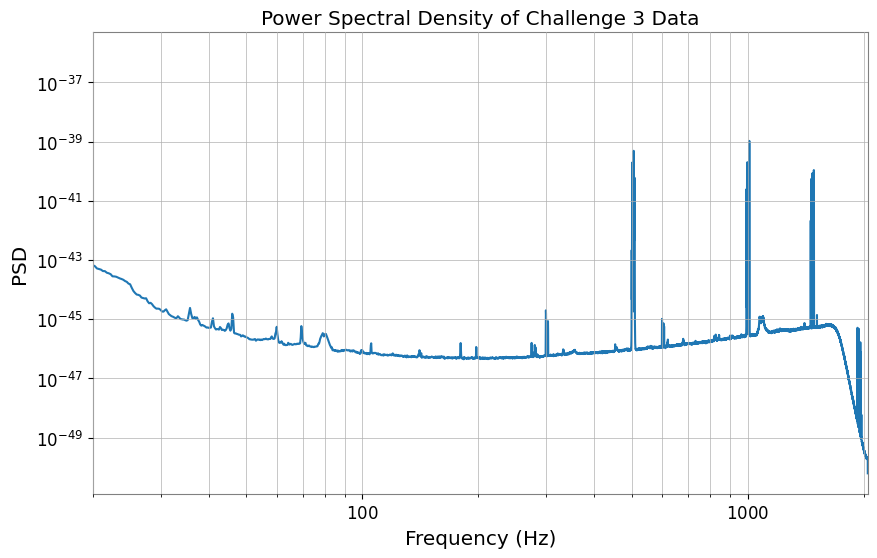

In [ ]:
# Step 4: Calculate the PSD of the data
# We ensure delta_f matches the data to avoid errors in matched_filter
delta_f = 1.0 / ts.duration.value
psd = ts.psd(4)

plt.figure(figsize=(10, 6))
plt.loglog(psd.frequencies, psd)
plt.xlim(20, ts.sample_rate.value / 2)
plt.xlabel('Frequency (Hz)')
plt.ylabel('PSD')
plt.title('Power Spectral Density of Challenge 3 Data')
plt.grid(True, which='both')
plt.show()

## Step 4: Calculate the SNR Time Series

Using the template and the PSD, we perform matched filtering to find the signal SNR.

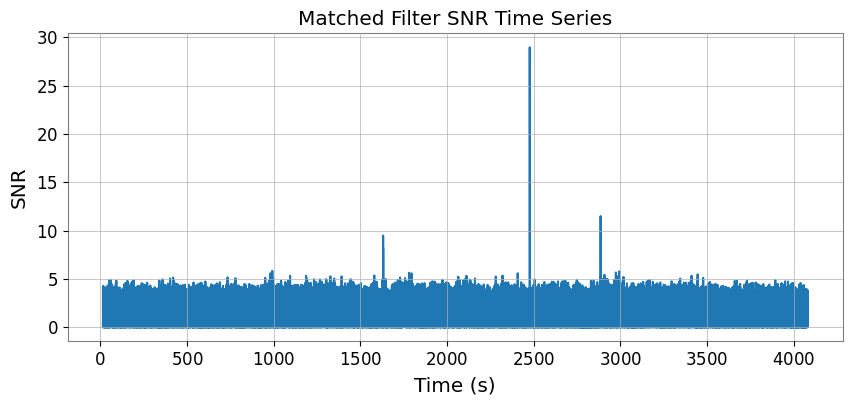

Peak SNR: 28.97 at 2477.99 seconds


In [ ]:
from pycbc.filter import matched_filter
from pycbc.types import TimeSeries as PyCBCTimeSeries

# Convert GWPy TimeSeries to PyCBC
pycbc_ts = ts.to_pycbc()
# Interpolate PSD to match the data's delta_f
pycbc_psd = psd.to_pycbc()
from pycbc.psd import interpolate
pycbc_psd = interpolate(pycbc_psd, pycbc_ts.delta_f)

# Resize the template to match the data length for matched_filter
hp.resize(len(pycbc_ts))

# Perform matched filtering
snr = matched_filter(hp, pycbc_ts, psd=pycbc_psd, low_frequency_cutoff=20, high_frequency_cutoff=500)

# Crop the edges to remove filter transients
snr = snr.crop(16, 16)

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 4))
plt.plot(snr.sample_times, abs(snr))
plt.ylabel('SNR')
plt.xlabel('Time (s)')
plt.title('Matched Filter SNR Time Series')
plt.grid(True)
plt.show()

# Find the peak
valid = (snr.sample_times > 50) & (snr.sample_times < snr.sample_times[-1] - 50)
snr_valid = abs(snr)[valid]

peak_snr = snr_valid.max()
peak_time = snr.sample_times[valid][snr_valid.argmax()]

print(f'Peak SNR: {peak_snr:.2f} at {peak_time:.2f} seconds')

### Questions for Challenge 3:

**A. What is the merger time of the loud signal?**

In [ ]:
# The peak values were calculated in the previous cell
print(f"From the SNR time plot, the peak is at {peak_time:.2f} seconds.")

From the SNR time plot, the peak is at 2477.99 seconds.


**B. What is the matched-filter SNR of the loud signal?**

In [ ]:
print(f"The matched filter SNR of the signal is {peak_snr:.2f}.")

The matched filter SNR of the signal is 28.97.
